In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_data(fname="s11.npz"):
    d = np.load(fname)
    print(list(d.keys()))
    freqs_MHz = d["freqs"] / 1e6
    s11 = 20 * np.log10(np.abs(d["calibrated_s11"]))
    fcut = freqs_MHz >=50
    f = freqs_MHz[fcut]
    s = s11[fcut]
    return f, s


def load_sim(fname="sparams.csv"):
    d = np.loadtxt(fname, delimiter=",", skiprows=1, usecols=(1, 2))
    f = d[:, 0]
    s = d[:, 1]
    return f, s

In [3]:
f, s = load_data()
f2, s2 = load_sim()

['freqs', 'calibrated_s11', 'vna', 'feed_cables', 'ns_cables']


These two panels are for inspection only. The published frequency-domain
figure is Fig. 3(a), produced together with the delay panel by
`s11_sim_meas.py` on the `s11-scripts` branch -- not by this notebook.
This notebook produces `reflections.pdf` (Fig. 2), below.


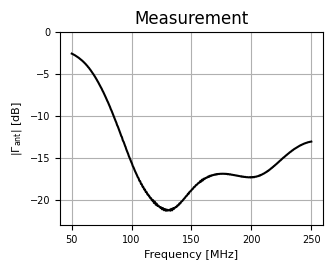

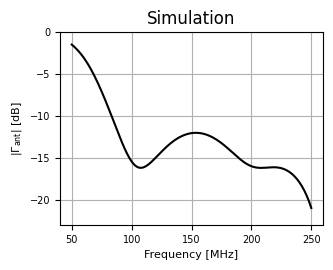

In [4]:
def plot(frequency, s11_dB, title=None, save=False, save_path="bowtie_s11.pdf"):
    plt.figure(figsize=(3.4, 2.5))
    plt.plot(frequency, s11_dB, c="k")
    plt.xlabel("Frequency [MHz]", fontsize=8)
    plt.ylabel("|$\\Gamma_{\\rm ant}$| [dB]", fontsize=8)
    plt.grid()
    plt.ylim(-23, 0)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    if title:
        plt.title(title)
    if save:
        plt.savefig(save_path, bbox_inches="tight", dpi=600)

plot(f, s, title="Measurement", save=False)
plot(f2, s2, title="Simulation", save=False)

In [19]:
def delay_plot(dly, dspec, title=None, save=False, save_path="reflections.pdf"):
    plt.figure(figsize=(3.4, 2.5))
    for h, d in dspec.items():
        plt.plot(np.fft.fftshift(dly), np.fft.fftshift(np.abs(d)), label=f"{float(h):3.0f} m")
    plt.xlabel("Delay [ns]", fontsize=8)
    plt.ylabel("Environmental Delay Spectrum [arb.]", fontsize=8)
    plt.grid()
    plt.xlim(0, 1000)
    plt.ylim(1e-11, 1) 
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.yscale("log")
    plt.legend(ncols=2, loc="upper right", fontsize=7)
    if title:
        plt.title(title)
    if save:
        plt.savefig(save_path, bbox_inches="tight", dpi=600)

In [20]:
dly_npz = np.load("s11_terrain.npz")
dspec = {}
for k, v in dly_npz.items():
    if k == "dly":
        dly = v
    else:
        dspec[k] = v

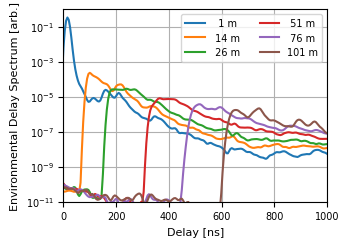

In [21]:
delay_plot(dly, dspec, save=True)